In [661]:
#All test files:
#1) "C:\Users\Bradley\Videos\New folder\AgBH_cali_5m_13.5kev_2_1961.7s_RH661.032_x0.300_th0.000_5.00s_458795_waxs.tiff"
#2) "C:\Users\Bradley\Videos\New folder\AgBH_cali_5m_13.5kev_6_2795.4s_RH-28.010_x0.300_th0.000_5.00s_458825_saxs.tiff"
#3) "C:\Users\Bradley\Videos\New folder\AgBH_cali_5m_13.5kev_WAXSx-193_y22_x0.300_th0.000_5.00s_1000930_waxs.tiff"
#4) "C:\Users\Bradley\Videos\New folder\AgBH_cali_5m_13.5kev_x0.000_y0.000_10.00s_988715_saxs.tiff"
#5) "C:\Users\Bradley\Videos\New folder\AgBH_cali_5m_13.5kev_x0.000_y0.000_10.00s_988715_waxs.tiff"

#6) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_5m_openarea_x0.450_th0.000_10.00s_1094599_saxs.tiff"
#7) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_3m_13.5kev_WAXSx-194_y17_x0.000_th0.000_10.00s_922280_waxs.tiff"
#8) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_3m_13.5kev_x1.000_th0.000_10.00s_916432_saxs.tiff"
#9) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_3m_WAXSx-195_y17_x0.000_th0.000_10.00s_954694_waxs.tiff"
#10) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_5m_13.5kev_1_34450.6s_x0.900_y-0.400_LinkamnanC_20.00s_892406_saxs.tiff"
#11) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_5m_13.5kev_WAXSx-195_y20_good_x0.300_th0.000_5.00s_1000932_waxs.tiff"
#12) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_5m_13.5kev_WAXSx-217_y20_x0.500_th0.000_5.00s_1160446_waxs.tiff"
#13) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_5m_13.5kev_WAXSx-225_y24_x0.300_th0.000_5.00s_1000919_waxs.tiff"
#14) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_5m_13.5kev_x0.000_y0.000_10.00s_1135050_saxs.tiff"
#15) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_cali_13.5kev_5m_sam7_2_360.1s_LinkamnanC_5.00s_1148340_saxs.tiff"
#16) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_MAXSx-65_y-55_346_5506.4s_T42.821C_x0.001_th0.250_10.00s_1166652_maxs.tiff"
#17) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_WAXSx-225_WAXSy22_13_x0.000_th0.000_10.00s_1136604_waxs.tiff"
#18) "C:\Users\Bradley\Videos\New folder\Second batch\AgBH_WAXSx-235_WAXSy45_11_x0.000_th0.000_10.00s_1136602_waxs.tiff"

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import math
import import_ipynb

In [668]:
file=r"C:\Users\Bradley\Videos\New folder\AgBH_cali_5m_13.5kev_6_2795.4s_RH-28.010_x0.300_th0.000_5.00s_458825_saxs.tiff"
img = Image.open(file)
npformconvert=file.replace("\\", "/")
npformconvert=npformconvert.replace("C:", "")
img2 = np.asarray(Image.open(npformconvert))
#For numpy version of file all backslashes are turned into forward slashes. Also no r C:

img.convert('I').show()

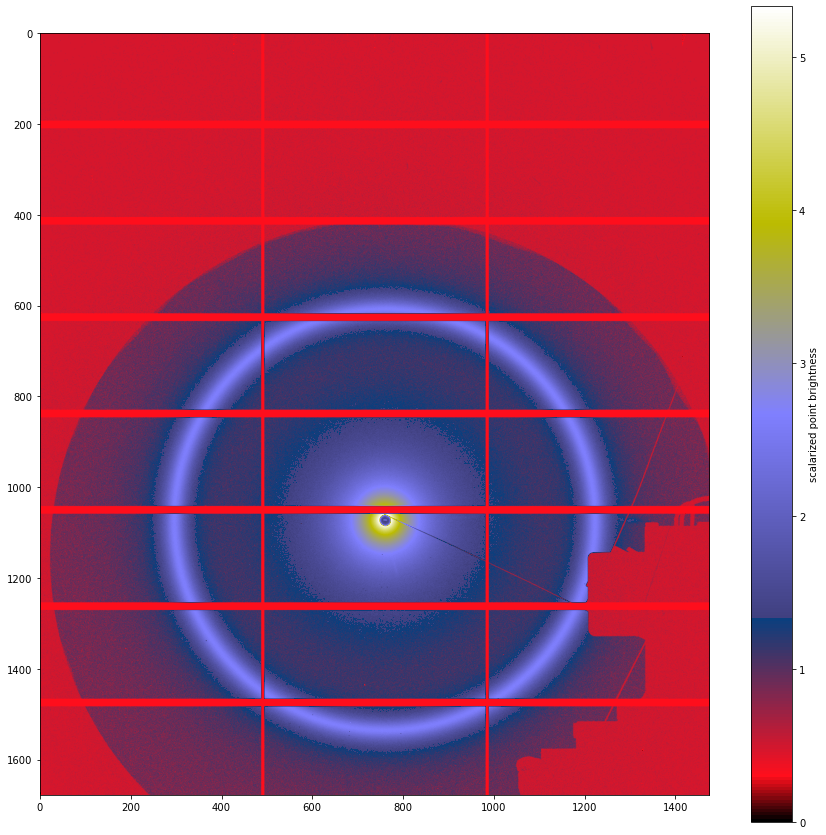

In [669]:
def plotter(dim): #creates plot
    plt.figure(100, figsize=(dim, dim))
    plt.imshow(np.log10(img2+3), cmap="gist_stern")
    cbar=plt.colorbar(label="scalarized point brightness")
    

#this method takes an array and if values are close together it "combines them". 
#It groups values that are less than 10 apart and then finds the average of these clusters. This forms a smaller array, 
#comprised of the averages. This array of averages is then averaged. This value is outputted. 
#METHOD USED FOR LIST OF INDICIES NOT INTENSITY VALUES    
def cluster_avg(val_list):
    hold_avgs=np.array([])
    hold_indices=np.array([])
    lastindex=0
    for j in range((len(val_list)-1)):#we don't want to go out of bounds. so keep the j+1 from going too far.
        if(save[j+1]>(val_list[j]+10)): #The +10 is just a number I have to be the amount above to split. So if values differ by 10, the array splits between these indices.
            for k in range(lastindex, (j+1)): #go from previous cluster's last index to the next one that starts a new cluster.
                hold_indices=np.append(hold_indices, val_list[k]) #put the cluster's indices in an array
            hold_avgs=np.append(hold_avgs, np.nanmean(hold_indices)) #put the mean of the cluster's indices in an array
            hold_indices=np.array([]) #empty the array that holds the indices
            lastindex=j+1 # move the last index up so we will not look at the same cluster again in our for loop
    
        elif(save[j+1]==val_list[-1]):
            for k in range(lastindex, (j+1)): #go from previous cluster's last index to the next one that starts a new cluster. This doesn't include the final array element
                hold_indices=np.append(hold_indices, val_list[k]) #put the cluster's indices in an array
            hold_indices=np.append(hold_indices, val_list[-1]) #include the final element of save
            hold_avgs=np.append(hold_avgs, np.nanmean(hold_indices)) #put the mean of the cluster's indices in an array
            hold_indices=np.array([]) #empty the array that holds the indices
            lastindex=j+1 # move the last index up so we will not look at the same cluster again in our for loop
    avg_of_clusters=np.nanmean(hold_avgs)  
    
    return(avg_of_clusters)


def cut_down(save_col,save_row):
    new_save_col=np.array([])
    new_save_row=np.array([])
    for i in range (len(save_row)-1):
        if(save_row[i]<save_row[i+1]+1 and save_row[i]<save_row[i+1]-1):
            new_save_col=np.append(new_save_col,save_col[i])
            new_save_row=np.append(new_save_row,save_row[i])
    return np.concatenate((new_save_col,new_save_row))


def cut_down_repeat(save_col,save_row,run_num_start): #make cut_down recursive
    while(run_num_start>1):
        full_save=np.array_split(cut_down(save_col,save_row), 2)  
        save_col=full_save[0]
        save_row=full_save[1]
        run_num_start-=1
    return np.concatenate((save_col,save_row))


def euclidean_distance_formula(x,y,a,b):
    d=((a-x)**2+(b-y)**2)**0.5
    return d

def outlier_removal(col_array,row_array):
    distances=np.array([]) #holds distances between points
    col_array_2=np.array([])
    row_array_2=np.array([])
    for i in range (len(col_array)-1):
        distances=np.append(distances,euclidean_distance_formula(col_array[i],row_array[i],col_array[i+1],row_array[i+1])) #finds distances between points
    for i in range (len(distances)):
        if(distances[i]<np.median(distances)):
            col_array_2=np.append(col_array_2,col_array[i])
            row_array_2=np.append(row_array_2,row_array[i])
    return(np.concatenate((col_array_2,row_array_2)))


def circle_of_best_fit(points):
    # Convert the input points to a numpy array
    points = np.array(points)

    # Compute the centroid of the points
    x_m, y_m = np.mean(points, axis=0)

    # Formulate the matrix A and the vector B
    A = np.hstack((2*points, np.ones((points.shape[0], 1))))
    B = np.sum(points**2, axis=1)

    # Solve the linear system A @ [x0, y0, R^2 - x0^2 - y0^2] = B
    x, y, C = np.linalg.lstsq(A, B, rcond=None)[0]

    # Compute the radius
    R = np.sqrt(x**2 + y**2 + C)

    return x, y, R



plotter(15)

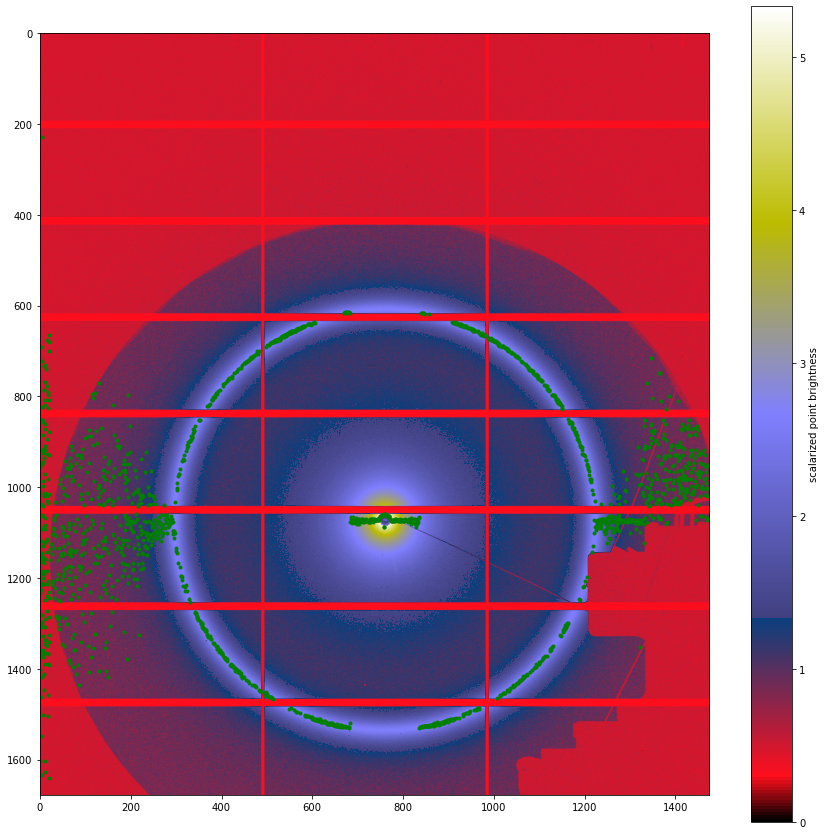

In [676]:
plotter(15) 

save_col=np.array([]) #the elements of this array are just each column in order so 0 to n incrementing by 1
save_row=np.array([])
for b in range(len(img2[0])): #go through every column and note that img2[0] is the size of the number of columns.
    lowerbound=0.999*np.amax(img2[:,b]) #get the actual max value in that column with amax and we want to see where values above this are. The high intensity values. I chose a 99.9% threshold.
    for m in range(len(img2[:,b])): #go through each index of the column
        if (img2[:,b][m]>lowerbound): #if the element is larger than our bound
            save_col=np.append(save_col,b) #get the indicies of the col
            save_row=np.append(save_row,m) #get corresponding row indicies
            plt.plot(b,m,"g.")


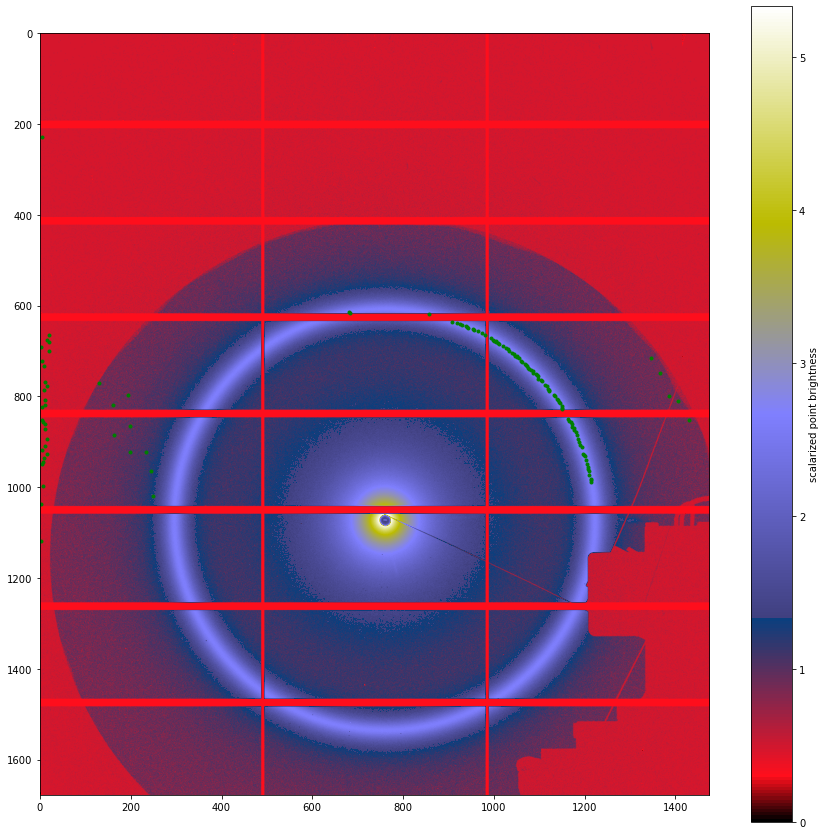

In [683]:
plotter(15) 

final_save=np.array_split(cut_down_repeat(save_col,save_row,10),2)
final_save_col=final_save[0]
final_save_row=final_save[1]

for i in range (len(final_save_col)):
    plt.plot(final_save_col[i],final_save_row[i],"g.")


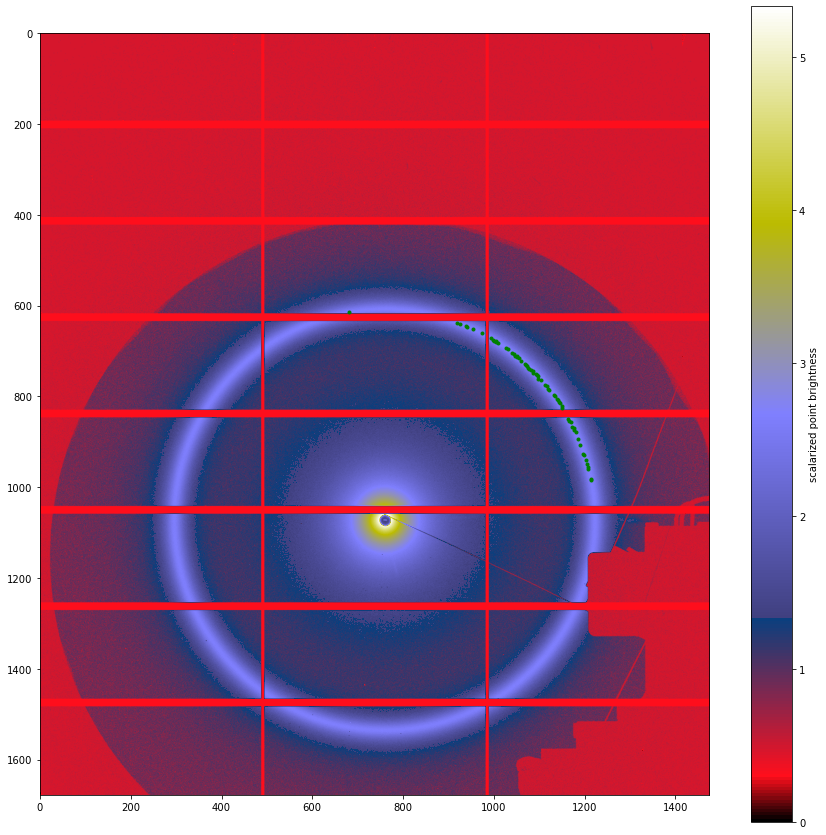

In [684]:
plotter(15)
points=np.array_split(outlier_removal(final_save_col,final_save_row),2)
col_points=points[0]
row_points=points[1]
for i in range (len(col_points)):
    plt.plot(col_points[i],row_points[i],"g.")

Center: (756.5423037724205,1073.9530358795203), Radius: 465.75128004655096)


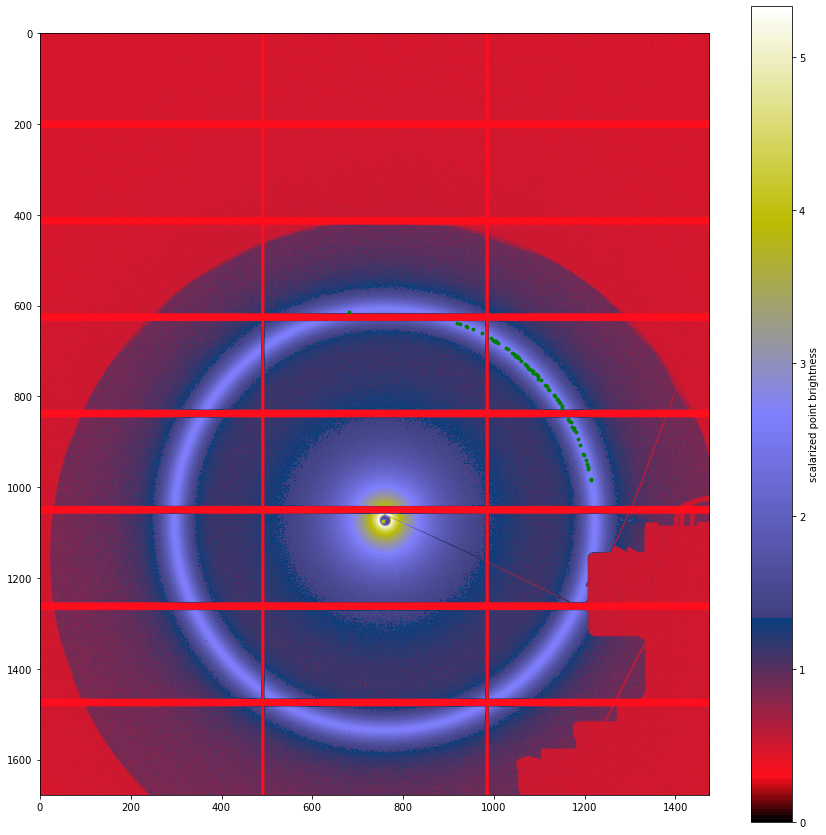

In [685]:
plotter(15)

point_list = list(zip(col_points, row_points))

for i in range (len(point_list)):
    plt.plot(point_list[i][0],point_list[i][1],"g.")
    
x0, y0, R = circle_of_best_fit(point_list)
print("Center: ("+str(x0)+","+str(y0)+"), Radius: "+str(R)+")")

plt.plot(x0,y0,"y.")

With cut_down 0 times Center: (735.6839647515693,1063.982396181986), Radius: 470.2503542385046)
With cut_down 1 times Center: (735.6839647515693,1063.982396181986), Radius: 470.2503542385046)
With cut_down 2 times Center: (723.007513560335,1087.5491657763644), Radius: 529.3085529098134)
With cut_down 3 times Center: (712.7364815893858,1093.647779178043), Radius: 562.5735976923005)
With cut_down 4 times Center: (675.9198422093317,1051.3115466309337), Radius: 560.5623145157098)
With cut_down 5 times Center: (665.4429063236286,1065.379356421519), Radius: 561.8477976804652)
With cut_down 6 times Center: (659.884464058894,1122.4097177444603), Radius: 588.2810728068584)
With cut_down 7 times Center: (639.2696461862927,1161.8640254288157), Radius: 610.6009624952812)
With cut_down 8 times Center: (645.089365202888,1174.4725013344862), Radius: 615.7945000080892)
With cut_down 9 times Center: (738.3345709291269,1090.6186673833106), Radius: 489.4458011352148)
With cut_down 10 times Center: (756.5

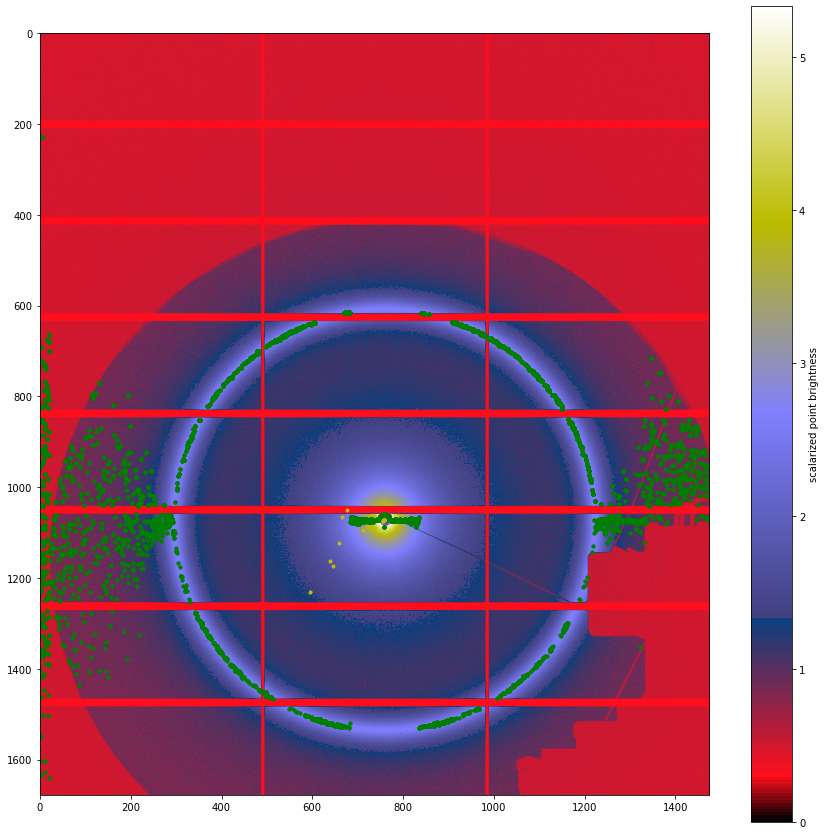

In [672]:
plotter(15) 
for i in range (20):
    

    final_save=np.array_split(cut_down_repeat(save_col,save_row,i),2)
    final_save_col=final_save[0]
    final_save_row=final_save[1]

    for j in range (len(final_save_col)):
        plt.plot(final_save_col[j],final_save_row[j],"g.")


    points=np.array_split(outlier_removal(final_save_col,final_save_row),2)
    col_points=points[0]
    row_points=points[1]
    for k in range (len(col_points)):
        plt.plot(col_points[k],row_points[k],"g.")

    point_list = list(zip(col_points, row_points))


    for l in range (len(point_list)):
        plt.plot(point_list[l][0],point_list[l][1],"g.")

    x0, y0, R = circle_of_best_fit(point_list)
    print("With cut_down "+str(i)+" times Center: ("+str(x0)+","+str(y0)+"), Radius: "+str(R)+")")

    plt.plot(x0,y0,"y.")